# Stage 3 – EDA, Step 5: Validity Checks

**Project:** Machine Learning-Based U.S. Residential Rental Price Estimation System
**Continues from:** `03_eda_missing_duplicates.ipynb` (Steps 3 and 4)

---

## Where we are in the EDA

So far we have dealt with three kinds of data problem:

- **Step 2 – wrong target values:** prices of \$0, \$1 and \$2.8 billion. Rule: keep \$100 to \$10,000.
- **Step 3 – absent values:** blanks in parking, laundry and coordinates. Rule: a `"missing"` category and a regional fill.
- **Step 4 – repeated values:** half the listings are copies. Rule: deduplicate on model features + price.

Step 5 deals with the fourth kind: values that are **present, but impossible or implausible**. A value can be filled in and still be wrong. Step 1 already spotted several:

- `sqfeet` of **0**, and a maximum of **8,388,607**. That is exactly 2²³ − 1, a number computers use as a "maximum" placeholder, not a real size;
- **1,100 bedrooms** and **75 bathrooms**;
- **latitude 102**, which cannot exist (latitude stops at 90), and points in the southern hemisphere;
- the `state` column not matching the location (Reno listings labelled `ca`).

Step 2 also left two leads for this step:

- homes **for sale** posted in the rental section, which may also hide inside the valid price range;
- a **heavy lower tail** of rents between about \$100 and \$250, which could be rooms, weekly rates or errors.

---

## Three kinds of validity rule

It helps to separate three kinds of check, because each needs a different level of proof:

1. **Hard limits: physically impossible values.** Latitude above 90, a home of 0 sq ft. No argument is needed; these are errors.
2. **Plausibility limits: possible in theory, but not credible for a rental listing.** 75 bathrooms, a 50,000 sq ft apartment. We choose the limit from the data (counts and real examples), just as we chose the price limits in Step 2.
3. **Consistency checks: each value is fine alone, but the combination is impossible.** Four bedrooms in 250 sq ft; coordinates 1,500 km away from the listing's own Craigslist region. These are the hardest errors to find, because no single column looks wrong.

## Two ways to fix an invalid value

- **Remove the row.** Used when the invalid value is a *core fact* about the listing (its size, bedrooms or bathrooms), or when the listing isn't a monthly rental at all. We can't trust the rest of a row whose basic description is wrong, and these are inputs the user will always type into the prediction system.
- **Set the value to missing and fill it.** Used for coordinates. A wrong map pin doesn't mean the listing is fake. Its region (`region_url`) is still known, so we blank the coordinates and let the Step 3 regional fill replace them.

**About this version of the notebook:** the first run of this notebook used *provisional* limits. After reading the output, several decisions changed. For example, 0 bathrooms turned out to mean "not entered", and the sale-wording rule turned out to be unreliable. Each check is now followed by a **"What our data showed"** block that explains the evidence and the final decision. The confirmed limits are stored in `src/utils.py`, and all the rules are implemented once in `src/cleaning.py` as the function `clean_data()`.

As before, **nothing is deleted in this notebook**. We measure, decide and record, and at the end we estimate how big the final modelling dataset will be once every rule from Steps 2–5 is applied.

**Which rows are counted?** Counts use **all 384,977 rows**, as in Steps 3 and 4. Each table also shows how many flagged rows are inside the **valid price range**, because those are the rows that would otherwise reach the model.

## 5.0 Setup

The same setup as the earlier notebooks: shared helpers and constants from `src/utils.py`, the parquet loaded with `load_raw()`, and `valid`, the Step 2 price rule as a True/False marker per row.

**The confirmed limits now come from `utils.py`**: `SQFT_MIN`, `SQFT_MAX`, `BEDS_MAX`, `BATHS_MIN`, `BATHS_MAX`, `MIN_SQFT_PER_ROOM`, `MAX_EXTRA_BATHS`, `US_LAT_RANGE`, `US_LON_RANGE`, `FAR_KM` and `RENT_FLOOR`. They're defined in one place so this notebook, the cleaning function and (later) the prediction platform's input checks all use exactly the same numbers.

Three small helper functions are defined here because every section uses them:

- **`flag_table(checks)`** takes a dictionary of named checks (each a True/False marker for every row) and builds a table with the number of flagged listings, their % of all rows, and how many of them are inside the valid price range.
- **`peek(mask)`** shows a random sample of listings that match a check, with the start of their description. Reading real examples is how we tell an error from a genuine unusual listing.
- **`pct_index(series)`** relabels a quantile table so its rows read "0.1%", "99%" and so on, instead of the confusing "0.00" and "1.00" the display settings would otherwise show.

In [ ]:
# 5.0 Setup

%load_ext autoreload
%autoreload 2

import re
import sys
import warnings
from pathlib import Path
sys.path.append(str(Path.cwd().parent))   # lets Python find the src/ folder

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils import *
from src.cleaning import clean_data, haversine_km, in_us_box, region_centres
setup_display()
warnings.filterwarnings("ignore", category=FutureWarning)

df_raw = load_raw()
df = df_raw.copy()
valid = df["price"].between(PRICE_MIN, PRICE_MAX)   # Step 2 rule

print(f"All rows:         {len(df):,}")
print(f"Valid-price rows: {valid.sum():,}")


def flag_table(checks):
    # One row per check: how many listings it flags, overall and inside the valid price range
    return pd.DataFrame({
        "listings": {name: int(m.sum()) for name, m in checks.items()},
        "%_of_all_rows": {name: m.mean() * 100 for name, m in checks.items()},
        "in_valid_price_range": {name: int((m & valid).sum()) for name, m in checks.items()},
    }).style.format({"listings": "{:,}", "%_of_all_rows": "{:.3f}%", "in_valid_price_range": "{:,}"})


SHOW_COLS = ["price", "type", "sqfeet", "beds", "baths", "region", "state", "description"]

def peek(mask, n=8, cols=SHOW_COLS):
    # Random sample of listings matching mask, with a shortened description
    n = min(n, int(mask.sum()))
    if n == 0:
        print("   (no listings match)")
        return None
    out = df.loc[mask, cols].sample(n, random_state=RANDOM_STATE).copy()
    if "description" in out:
        out["description"] = out["description"].str.slice(0, 100)
    with pd.option_context("display.max_colwidth", 110):
        display(out)


def pct_index(series):
    # Label quantile rows as percentages, e.g. 0.001 -> "0.1%"
    return series.rename(lambda q: f"{q * 100:g}%")

show_obs(4)   # Step 4 findings, to confirm the handover

All rows:         384,977
Valid-price rows: 382,494


,step,observation,evidence,decision
0,4-Duplicates,No exact duplicate rows (0); every id is unique,4.1 level 1,Exact-duplicate removal alone would miss the p...
1,4-Duplicates,"46,544 extra copies (12.09%) are reposts: iden...","4.1 level 2, 4.2 example group",Remove reposts before the train/test split
2,4-Duplicates,"191,384 extra copies (49.71%) are identical to...","4.1 level 4, 4.3 largest groups","Deduplicate on model features + price, keeping..."
3,4-Duplicates,"Without deduplication, 58.9% of test rows have...",4.4 leakage simulation,Deduplicate BEFORE splitting to prevent leakag...
4,4-Duplicates,"203,909 listings reuse a photo from another li...",4.1 level 5,Evidence only: different real units can share ...
5,4-Duplicates,Cleaning order matters: fixing values can crea...,Reasoning from Steps 2-5,Step 7 order: price rule -> validity fixes (St...
6,4-Duplicates,Level-4 deduplication removes 50% of valid row...,4.4 rows_before_split,Still ample for all five models; from Step 6 o...


## 5.1 Square footage (`sqfeet`)

**What this cell does:** it shows the extreme quantiles of `sqfeet` (as we did for price in Step 2.1), counts listings at several low and high thresholds, lists the most repeated very large values, and shows real examples from both ends.

**Why we do it:** size is one of the strongest drivers of rent, and one of the inputs a user will type into the prediction system. An impossible size corrupts the most important relationship the model has to learn: the model would see "0 sq ft costs \$1,500" or "8 million sq ft costs \$900" and try to make sense of it.

**What to look for in the output:**

- **Zeros.** Craigslist may store 0 when the poster left the field empty. So a 0 is really a hidden *missing value*, not a tiny home.
- **Placeholder values.** 8,388,607 = 2²³ − 1 is the largest number some systems store in a fixed-size field. If it appears several times, it's a system artefact, not a typo. Other suspicious values are round numbers like 1,000,000.
- **The boundary between real and fake.** Look at the examples just above 5,000 sq ft. Some large houses are genuine (like the luxury homes in Step 2). Listings of 50,000 sq ft with 2 bedrooms are clearly not.

**A useful comparison:** a standard car parking space is about 160 sq ft. A whole home under 100 sq ft is smaller than half a parking space, which is not credible for a rental listing.

In [ ]:
# 5.1 sqfeet: extreme quantiles, threshold counts, repeated large values

sq = df["sqfeet"]
quantiles = [0, 0.001, 0.005, 0.01, 0.05, 0.5, 0.95, 0.99, 0.995, 0.999, 0.9999, 1]
display(pct_index(sq.quantile(quantiles)).rename("sqfeet").to_frame())

sqft_checks = {
    "sqfeet == 0": sq.eq(0),
    "sqfeet < 100": sq.lt(100),
    "sqfeet < 150": sq.lt(150),
    "sqfeet < 200": sq.lt(200),
    "sqfeet > 5,000": sq.gt(5_000),
    "sqfeet > 10,000": sq.gt(10_000),
    "sqfeet > 20,000": sq.gt(20_000),
    "sqfeet == 8,388,607 (2^23 - 1)": sq.eq(8_388_607),
}
display(flag_table(sqft_checks))

print("Most common sqfeet values above 10,000:")
display(sq[sq > 10_000].value_counts().head(10).rename("listings"))

,sqfeet
0%,0.00
0.1%,25.00
0.5%,270.00
1%,340.00
5%,536.00
50%,949.00
95%,"1,642.00"
99%,"2,405.00"
99.5%,"2,800.00"
99.9%,"4,200.00"


,listings,%_of_all_rows,in_valid_price_range
sqfeet == 0,48,0.012%,48
sqfeet < 100,976,0.254%,955
sqfeet < 150,"1,072",0.278%,"1,047"
sqfeet < 200,"1,179",0.306%,"1,154"
"sqfeet > 5,000",273,0.071%,235
"sqfeet > 10,000",82,0.021%,79
"sqfeet > 20,000",35,0.009%,33
"sqfeet == 8,388,607 (2^23 - 1)",1,0.000%,1


Most common sqfeet values above 10,000:


sqfeet
11000      6
50000      5
999999     4
12000      3
20000      3
1019856    2
23000      2
11500      2
13600      2
17951      1
Name: listings, dtype: int64

In [ ]:
# 5.1 (cont.) Real examples at both ends

print("Listings under 100 sq ft")
peek(sq.between(1, 99))
print("Listings of 5,001 to 10,000 sq ft")
peek(sq.between(5_001, 10_000))
print("Listings over 10,000 sq ft")
peek(sq.gt(10_000))

# Findings to note: are the small ones rooms, parking spaces, or typos (e.g. 85 instead of 850)?
# Are the 5k-10k ones real large houses? Are the >10k ones all nonsense?

Listings under 100 sq ft


,price,type,sqfeet,beds,baths,region,state,description
310061,1075,condo,35,2,2.00,san marcos,tx,"Lovely 2/2 downstairs condo in super location. Enjoy the convenience of living at the quiet, tree s"
266775,500,house,50,1,1.00,greenville / upstate,sc,Original hard wood floors in living and bedroom. Semi shaded fenced in back yard and large cleaned o
8388,3078,apartment,39,2,1.00,SF bay area,ca,"SEACLIFF APARTMENTS 300 Palmetto Avenue Pacifica, CA 94044 Phone: show contact info Website:"
195137,0,apartment,1,1,1.00,lincoln,ne,"Bedrooms: 1 Bathrooms: 1 Price: $0 Welcome to Homestead Village, apartments for seniors 62+ and dis"
97730,695,house,30,3,1.00,evansville,in,$99 Move in Special !!! Charming 3 bedroom home with New flooring throughout this home as well as a
179056,1195,condo,75,3,2.50,charlotte,nc,"3Bedroom, 2 Â½ Bath. Condo. Comedor. Sala. Aire Central. Calef/ Gas. Estufa. Nevera. Lavaplatos. Pat"
74118,595,apartment,50,1,1.00,columbus,ga,1 Month Free with 13 Month Lease or 2 Weeks Free with 12 Month Lease https://midtownpark.rentals
232673,595,apartment,1,2,1.00,mansfield,oh,All Utilities Paid on the following properties: 146 S Main St. - #3 \t$450 mo./$450


Listings of 5,001 to 10,000 sq ft


,price,type,sqfeet,beds,baths,region,state,description
319109,4800,house,5417,5,3.50,salt lake city,ut,Stunning home in the coveted area of Holladay. Very open floor plan with the main level partially re
153457,440,house,7000,0,3.50,kalamazoo,mi,K College an6d WMU Students Luxury Student Living BEAUTIFUL 10 to 12 BEDROOM 4 BATH HOME Lease NOW
326322,1100,house,5696,5,4.50,new river valley,va,Great price reduction on this idyllic North Arlington home on quiet street yet minutes to DC!! Beaut
139682,1900,apartment,9999,1,1.00,boston,ma,Amazing 1 bed split. Available 9/1/20. Broker Fee Required. has a kitchen equipped with granite cou
128671,4000,house,5232,5,4.50,new orleans,la,Call Jennifer Today to schedule a private showing! show contact info EZ Qualifying! and LOW down
14042,16010,house,7237,5,5.00,ventura county,ca,"Beautiful 5 bedroom, and additional 2 bonus rooms, 2 offices, library, & 2 bath North Ranch home sit"
7688,15750,house,6000,7,5.00,SF bay area,ca,- Newly renovated home located in the quiet neighborhood of Tobin Clark Estates. - The house is a
15677,8000,house,8112,6,7.00,boulder,co,Rare 6 Bed 7 Bath Tudor Home Offering Panoramic Views & Surrounded by Open Space! Prop


Listings over 10,000 sq ft


,price,type,sqfeet,beds,baths,region,state,description
140006,2175,apartment,11000,2,1.00,boston,ma,"Spacious Two Bedroom Apartment in highly desired part of East Cambridge. We have 1st, 2nd and 3rd"
625,1995,house,17951,3,2.00,reno / tahoe,ca,3 bedrooms/2 bathrooms/2 car garage/game room/1795 sq. ft. approx./no smoking/has AC (brand new unit
95090,350,house,63134,2,1.00,"st louis, MO",il,It comes with a stove and refrigerator. It has a full basement that is freshly painted.
140610,2175,apartment,11000,1,1.00,boston,ma,"Spacious Two Bedroom Apartment in highly desired part of East Cambridge. We have 1st, 2nd and 3rd"
81369,2500,house,10048,3,2.00,hawaii,hi,"House for rent at Woodlawn Dr, is a house in Honolulu, HI 96822. This 1,618 square foot house sits o"
113129,1450,house,18000,3,2.00,lake charles,la,"Home for rent $1,450 per month. $1,000 security deposit Three bedroom two bath large living, sitti"
53876,1100,house,12000,3,1.00,pensacola,fl,"1002 Dominquez St Pensacola, FL 32505$1100.00 / Month---------------------------Interested in this"
222542,1900,house,50000,3,2.00,north dakota,nd,"5 acres seller financing $99,000 with or without a house for rent county board zoned light commerci"


### 5.1 What our data showed, and the decision

**Tiny sizes are typos, not tiny homes.** There are 976 listings under 100 sq ft (48 of them exactly 0). The examples are ordinary homes with an impossible size: a "lovely 2/2 condo" of 35 sq ft, a 3-bedroom house of 30 sq ft, a 3-bed condo of 75 sq ft. The poster most likely dropped a digit (75 instead of 750) or typed something else into the size field. The rent is real, but the size is wrong, and size is exactly what the model needs to learn from.

**5,001–10,000 sq ft is mostly genuine.** Large family houses in Salt Lake City, Boulder and the SF Bay Area, with 5–7 bedrooms and matching rents. A few odd ones remain (a 1-bed Boston apartment of 9,999 sq ft, a 0-bed "10 to 12 bedroom" student house), but the consistency checks in 5.4 and the price-per-square-foot checks in Step 6 catch those.

**Above 10,000 sq ft is nonsense.** Repeated round numbers (11,000; 50,000; 999,999), plus clear typos: a house listed at 17,951 sq ft whose description says "1795 sq. ft.", and a Honolulu house at 10,048 sq ft whose description says 1,618. Only one listing has the 8,388,607 placeholder, so that's a curiosity rather than a big problem.

**Decision:** keep sizes from **100 to 10,000 sq ft** (`SQFT_MIN`, `SQFT_MAX`) and remove the rest: **1,058 listings (0.27%)**. We remove rather than guess a size, because size is a core fact the user always enters, and a guessed size would teach the model a relationship that was never observed.

In [ ]:
# 5.1 (cont.) The confirmed sqfeet rule

bad_sqft = ~sq.between(SQFT_MIN, SQFT_MAX)
print(f"sqfeet outside {SQFT_MIN:,}-{SQFT_MAX:,}: {bad_sqft.sum():,} listings ({bad_sqft.mean() * 100:.2f}%), "
      f"{(bad_sqft & valid).sum():,} of them in the valid price range")

sqfeet outside 100-10,000: 1,058 listings (0.27%), 1,034 of them in the valid price range


## 5.2 Bedrooms (`beds`)

**What this cell does:** it lists every distinct bedroom count with how many listings have it, then counts listings above several thresholds and shows examples of the very high ones.

**Why we do it:** a full value count is practical here because `beds` has only a few dozen distinct values. It shows the normal range (0 to 4 or 5) and makes the absurd values stand out immediately.

**How to read the output:**

- **0 bedrooms is valid.** It means a **studio**, where the living room is also the bedroom. We keep it.
- **5–8 bedrooms** is possible for large houses, and fairly common in student towns where houses are shared.
- **Above 8** it's worth reading the examples. A listing with 1,100 bedrooms, or 12 bedrooms in 900 sq ft, is a typing error. Sometimes the poster typed the *number of units in the building* or the *size* into the wrong field.

In [ ]:
# 5.2 beds: every value, threshold counts, examples

beds = df["beds"]
beds_counts = beds.value_counts().sort_index().rename("listings")
print("Every bedroom count in the data:")
display(beds_counts.to_frame().T)

beds_checks = {
    "beds == 0 (studio, valid)": beds.eq(0),
    "beds > 5": beds.gt(5),
    "beds > 6": beds.gt(6),
    "beds > 8": beds.gt(8),
    "beds > 20": beds.gt(20),
}
display(flag_table(beds_checks))

print("Listings with more than 8 bedrooms")
peek(beds.gt(8))

bad_beds = beds.gt(BEDS_MAX)
print(f"Confirmed rule beds <= {BEDS_MAX}: flags {bad_beds.sum():,} listings "
      f"({(bad_beds & valid).sum():,} in the valid price range)")

Every bedroom count in the data:


beds,0,1,2,3,4,5,6,7,8,1000,1100
listings,10978,117226,175513,67037,11575,2324,240,49,31,2,2


,listings,%_of_all_rows,in_valid_price_range
"beds == 0 (studio, valid)","10,978",2.852%,"10,932"
beds > 5,324,0.084%,300
beds > 6,84,0.022%,71
beds > 8,4,0.001%,4
beds > 20,4,0.001%,4


Listings with more than 8 bedrooms


,price,type,sqfeet,beds,baths,region,state,description
89776,2449,apartment,1000,1100,75.00,chicago,il,Furnished or Unfurnished Units Includes Parking Newly Remodeled Short or Long Term Leases availabl
235159,550,apartment,250,1000,25.00,youngstown,oh,2 bedroom
37695,1500,land,100,1000,35.00,florida keys,fl,Only one lot available now from now to January 9th and available again in after April 1st One month
90779,2449,apartment,1000,1100,75.00,chicago,il,Furnished or Unfurnished Units Includes Parking Newly Remodeled Short or Long Term Leases availabl


Confirmed rule beds <= 8: flags 4 listings (4 in the valid price range)


### 5.2 What our data showed, and the decision

The bedroom counts are very clean. Every value from 0 to 8 is plausible:

- **0 beds:** 10,978 studios;
- **6–8 beds:** 320 listings, which are large houses and shared student houses;
- **above 8:** exactly **4 listings**, with 1,000 or 1,100 bedrooms. Two of them are the same Chicago listing (1,100 beds and 75 baths), and one is a "land" plot in the Florida Keys with 1,000 beds and 35 baths.

There's no grey area here: nothing between 9 and 999.

**Decision:** keep **0–8 bedrooms** (`BEDS_MAX = 8`) and remove the 4 impossible listings.

## 5.3 Bathrooms (`baths`)

**What this cell does:** the same approach as for bedrooms: every value with its count, threshold counts, and examples. It also checks two things specific to bathrooms:

- **values that aren't multiples of 0.5** (like 1.25 or 1.7), which shouldn't exist, because U.S. listings count bathrooms in halves;
- **0 bathrooms.**

**Why we do it, and how to read it:**

- **Half values are normal.** A "half bath" is a toilet and sink with no shower, so 1.5 or 2.5 baths is ordinary (Step 1 found them in 10.9% of listings).
- **0 bathrooms is questionable.** In theory it could describe a room in a shared house with a bathroom down the hall. But it could also be a hidden "not entered", just like `sqfeet = 0`. The examples decide which it is.
- **Above 8 bathrooms**, as with bedrooms, the examples will show whether they are real mansions or typing errors (Step 1 found 25, 35 and 75).

In [ ]:
# 5.3 baths: every value, special checks, examples

baths = df["baths"]
print("Every bathroom count in the data:")
display(baths.value_counts().sort_index().rename("listings").to_frame().T)

baths_checks = {
    "baths == 0": baths.eq(0),
    "baths not a multiple of 0.5": (baths * 2 % 1) != 0,
    "baths > 4": baths.gt(4),
    "baths > 6": baths.gt(6),
    "baths > 8": baths.gt(8),
}
display(flag_table(baths_checks))

print("Listings with 0 bathrooms")
peek(baths.eq(0))
print("Listings with more than 8 bathrooms")
peek(baths.gt(8))

bad_baths = ~baths.between(BATHS_MIN, BATHS_MAX)
print(f"Confirmed rule {BATHS_MIN} <= baths <= {BATHS_MAX}: flags {bad_baths.sum():,} listings "
      f"({(bad_baths & valid).sum():,} in the valid price range)")

Every bathroom count in the data:


baths,0.00,1.00,1.50,2.00,2.50,3.00,3.50,4.00,4.50,5.00,5.50,6.00,6.50,7.00,7.50,8.00,8.50,25.00,35.00,75.00
listings,3107,198184,27363,134649,13162,5549,1007,1495,231,131,57,26,4,4,2,1,1,1,1,2


,listings,%_of_all_rows,in_valid_price_range
baths == 0,"3,107",0.807%,"3,078"
baths not a multiple of 0.5,0,0.000%,0
baths > 4,461,0.120%,386
baths > 6,16,0.004%,13
baths > 8,5,0.001%,4


Listings with 0 bathrooms


,price,type,sqfeet,beds,baths,region,state,description
30124,900,apartment,670,1,0.00,new haven,ct,Nice sized 1 bedroom apartments in well maintained buildings under $1000. Ask me about our differen
57617,1300,apartment,748,1,0.00,south florida,fl,This quaint community in Boca Raton is centrally located close to 95 and the Boca Town Center Mall!
337654,1500,apartment,1500,1,0.00,seattle-tacoma,wa,"We are renting out 2 rooms out of our beloved hotel, wifi, cable, internet, hot water, utilities all"
230703,989,apartment,959,3,0.00,columbus,oh,"Call show contact info if you have any questions!Located in the middle of shopping, dinning and m"
58507,969,apartment,718,1,0.00,space coast,fl,To schedule a tour We now book our tour appointments online! Please call or text us at show contac
340466,600,apartment,900,3,0.00,appleton-oshkosh-FDL,wi,Remodeled apartments some with new kitchens
276422,825,apartment,910,1,0.00,jackson,tn,LUXURIOUS AMENITIES AT WOODS OF POST HOUSE APARTMENTS!Lose yourself in a relaxing afternoon by our s
56953,1975,apartment,843,1,0.00,south florida,fl,This prime downtown Delray Beach location is like no other! If you are looking for a fun and excitin


Listings with more than 8 bathrooms


,price,type,sqfeet,beds,baths,region,state,description
37695,1500,land,100,1000,35.00,florida keys,fl,Only one lot available now from now to January 9th and available again in after April 1st One month
235159,550,apartment,250,1000,25.00,youngstown,oh,2 bedroom
89776,2449,apartment,1000,1100,75.00,chicago,il,Furnished or Unfurnished Units Includes Parking Newly Remodeled Short or Long Term Leases availabl
37586,12000000,apartment,9000,7,8.50,florida keys,fl,"MANSION IN THE SKY!!! Breathtaking oceanfront 9,000 square foot, 7 bedroom, 8.5 bathrooms 2-story Pe"
90779,2449,apartment,1000,1100,75.00,chicago,il,Furnished or Unfurnished Units Includes Parking Newly Remodeled Short or Long Term Leases availabl


Confirmed rule 0.5 <= baths <= 8: flags 3,112 listings (3,082 in the valid price range)


### 5.3 What our data showed, and the decision

**Half-baths are all clean.** No value is anything other than a multiple of 0.5.

**0 bathrooms means "not entered".** This is the important finding. There are 3,107 listings with 0 baths, and the examples are *ordinary* apartments: a 1-bed in a "quaint community in Boca Raton", a luxury complex in Jackson TN, a 3-bed remodelled apartment in Wisconsin, a "prime downtown Delray Beach" 1-bed at \$1,975. None of them mention shared bathrooms. These homes certainly have a bathroom; the poster just left the field at 0. So `baths = 0` is a hidden missing value, exactly like `sqfeet = 0`.

**Above 8 bathrooms:** 5 listings, the same absurd rows found in 5.2 (25, 35, 75 baths), plus one 8.5-bath \$12 million "mansion in the sky", which the price rule removes anyway.

**Decision:** keep **0.5 to 8 bathrooms** (`BATHS_MIN = 0.5`, `BATHS_MAX = 8`), and remove the 0-bath listings (about 0.8% of rows). We could guess the number of bathrooms from the number of bedrooms instead. But removing keeps the rule simple and consistent with how we treat `sqfeet = 0`, and the data loss is small. The prediction platform will require at least 0.5 baths.

## 5.4 Do size, bedrooms and bathrooms fit together?

This is the first **consistency check**: values that pass their own limits but make no sense together.

**Check 1 – space per room.** We divide the size by the number of rooms, counting the bedrooms plus one living area: `sqfeet / (beds + 1)`. U.S. building codes generally require a habitable room to be at least **70 sq ft**, so a home with less than 70 sq ft per room can't physically contain the rooms it claims. For example, 3 bedrooms in 200 sq ft gives 50 sq ft per room.

**Check 2 – bathrooms vs bedrooms.** Homes rarely have many more bathrooms than bedrooms. A 1-bedroom apartment with 5 bathrooms most likely has the two numbers swapped or mistyped. We flag listings where `baths > beds + 3`, a generous margin that still allows, for example, a 2-bed house with 3.5 baths.

**Why only rows that passed 5.1–5.3?** Rows already failing the size, bedroom or bathroom limits will be removed anyway. Checking only the remaining rows shows how many *extra* errors the consistency rules catch. That's the real value of this step.

**How to read the output:** the counts show how common each problem is, and the examples show whether flagged rows really are errors. If check 2 mostly flagged genuine large houses, we'd keep it as a warning only rather than a removal rule.

In [ ]:
# 5.4 Consistency between size, bedrooms and bathrooms

passes_basic = ~bad_sqft & ~bad_beds & ~bad_baths
sqft_per_room = df["sqfeet"] / (df["beds"] + 1)

tiny_rooms = passes_basic & sqft_per_room.lt(MIN_SQFT_PER_ROOM)
too_many_baths = passes_basic & (df["baths"] > df["beds"] + MAX_EXTRA_BATHS)

display(flag_table({
    "under 70 sq ft per room": tiny_rooms,
    "baths > beds + 3": too_many_baths,
}))

print("Listings with under 70 sq ft per room")
peek(tiny_rooms)
print("Listings with baths > beds + 3")
peek(too_many_baths)

# Findings to note: are the tiny-room rows typos in sqfeet (e.g. 90 instead of 900)?
# Are the many-bath rows swapped fields, or genuine?

,listings,%_of_all_rows,in_valid_price_range
under 70 sq ft per room,114,0.030%,113
baths > beds + 3,32,0.008%,32


Listings with under 70 sq ft per room


,price,type,sqfeet,beds,baths,region,state,description
258924,699,apartment,133,1,1.00,york,pa,"Looking for a roommate for January - it's a 3 bedroom, 2 bathroom apartment and you would lease out"
5955,2650,apartment,100,3,1.50,SF bay area,ca,"Townhouse: 3 Bed, 1.5 Bath, 1199 sq.ft., (1 Full bath, 1 Half bath) Address: 38627 Cherry lane Unit"
100614,683,apartment,113,2,2.00,indianapolis,in,"2 Bed 2 BathCall: show contact info 3011 E 47th StIndianapolis, Indiana 46205-1658United StatesRent:"
229791,1360,townhouse,158,2,1.50,columbus,oh,"Elegance and style await; with select features including crown molding, twelve foot ceilings, open f"
25138,1025,apartment,244,3,1.00,fort collins / north CO,co,"About 1620 Smith Place This is a 3 bedroom, 1 bath ranch home on 1244 sq. ft., in central Fort Colli"
116376,1225,apartment,132,4,2.00,topeka,ks,College Hill Apartments are redefining the standard of luxury living in Topeka. Convenience coupled
240526,725,apartment,100,2,2.00,tulsa,ok,"Welcome to Bellevue at Sheridan! 10011 S Sheridan RD, Tulsa, Oklahoma 74133 Stop in or call us to"
215777,1595,apartment,138,2,2.00,syracuse,ny,"CANAL CROSSING APARTMENTS OFFERS UPSCALE, BOUTIQUE LIVING IN CAMILLUS, NY. OUR SPACIOUS ONE AND TWO-"


Listings with baths > beds + 3


,price,type,sqfeet,beds,baths,region,state,description
332274,425,apartment,190,2,6.00,bellingham,wa,Check out www.sternberghall.org. We have a small dormitory with 14 sleeping rooms (most of them are
153875,440,house,7000,0,3.50,kalamazoo,mi,Luxury Student Living K College and WMU BEAUTIFUL 10-12 BEDROOMS 4 BATH HOME Lease NOW for August
308157,895,apartment,1182,1,5.00,san antonio,tx,"Welcome to Park Greene Townhomes, and escape the bustle of professional life and enter a private vis"
153973,440,house,7000,0,3.50,kalamazoo,mi,"Luxury Student Living BEAUTIFUL 12 BEDROOMS 4 BATH HOME Lease NOW for August 18, 2020 for a Student"
153496,440,house,7000,0,3.50,kalamazoo,mi,K College an6d WMU Students Luxury Student Living BEAUTIFUL 10 to 12 BEDROOM 4 BATH HOME Lease NOW
153547,440,house,7000,0,3.50,kalamazoo,mi,Amazing Student Rental Home K College and WMU Students Luxury Student Living BEAUTIFUL 10 to 12 BEDR
332277,425,apartment,190,2,6.00,bellingham,wa,Check out www.sternberghall.org. We have a small dormitory with 14 sleeping rooms (most of them are
308739,895,apartment,1182,1,5.00,san antonio,tx,"Welcome to Park Greene Townhomes, and escape the bustle of professional life and enter a private vis"


### 5.4 What our data showed, and the decision

**Under 70 sq ft per room (122 listings): errors or rooms-for-rent.** Examples: a 3-bed townhouse "listed" at 200 sq ft, and a 3-bed SF Bay townhouse at 100 sq ft whose description says 1,199 sq ft (a clear typo). Others are rooms rented weekly in shared houses, where the size and bedrooms describe the whole house but the price is for one room.

**baths > beds + 3 (32 listings): every example is an error or per-room pricing.** Examples:

- a Kalamazoo student house with "10 to 12 bedrooms" entered as **0** beds, 3.5 baths, 7,000 sq ft, at \$440, which is clearly the price *per room*;
- a Bellingham dormitory with 14 sleeping rooms entered as 2 beds and 6 baths, \$425 per room;
- a San Antonio 1-bed with 5 baths.

Because every example was wrong, this is **promoted from a warning to a removal rule**.

**Decision:** remove listings with under 70 sq ft per room (`MIN_SQFT_PER_ROOM`) or with more than `beds + 3` bathrooms (`MAX_EXTRA_BATHS`). Together that's about 150 listings (0.04%).

## 5.5 Coordinates outside the United States

**What this cell does:** it checks every located listing against a simple box around U.S. territory:

- **latitude 18° to 72°**, from the south of Hawaii and Puerto Rico up to northern Alaska;
- **longitude −180° to −65°**, from the western Aleutian Islands in Alaska to the east coast of Maine.

Anything outside the box is broken into the likely cause:

- **latitude above 90 or below −90:** impossible anywhere on Earth (hard limit);
- **negative latitude:** southern hemisphere, e.g. the −43.5 found in Step 1;
- **positive longitude:** eastern hemisphere, e.g. the 172.63 found in Step 1;
- **other:** on Earth, but outside the U.S.

It also tests whether a simple **sign flip** would put the point back inside the U.S. For example, a longitude typed as 119.8 instead of −119.8.

**Why we do it:** coordinates feed the model directly (as numbers), and they're also used to fill missing coordinates in Step 3. A point in the Indian Ocean would distort both.

**The decision, and why we don't "repair" sign flips:** even if flipping a sign puts a point inside the U.S., we can't be sure it's the *right* point. The safer fix is to set the coordinates to missing and let the Step 3 regional fill place the listing at its region's centre. That's always roughly right, because the region is known.

In [ ]:
# 5.5 Coordinates outside a U.S. bounding box

lat, lon = df["lat"], df["long"]
located = lat.notna()
LAT_RANGE, LON_RANGE = US_LAT_RANGE, US_LON_RANGE

in_us = lat.between(*LAT_RANGE) & lon.between(*LON_RANGE)
outside_us = located & ~in_us

coord_checks = {
    "outside U.S. box (all causes)": outside_us,
    "|latitude| > 90 (impossible)": located & lat.abs().gt(90),
    "negative latitude (southern hemisphere)": located & lat.lt(0),
    "positive longitude (eastern hemisphere)": located & lon.gt(0),
    "fixable by flipping one sign": outside_us & ((-lat).between(*LAT_RANGE) & lon.between(*LON_RANGE)
                                                  | lat.between(*LAT_RANGE) & (-lon).between(*LON_RANGE)),
}
display(flag_table(coord_checks))

print("Listings with coordinates outside the U.S.")
peek(outside_us, cols=["price", "type", "region", "state", "lat", "long", "description"])

,listings,%_of_all_rows,in_valid_price_range
outside U.S. box (all causes),262,0.068%,262
|latitude| > 90 (impossible),4,0.001%,4
negative latitude (southern hemisphere),7,0.002%,7
positive longitude (eastern hemisphere),241,0.063%,241
fixable by flipping one sign,243,0.063%,243


Listings with coordinates outside the U.S.


,price,type,region,state,lat,long,description
364971,835,apartment,fayetteville,ar,36.22,94.12,Details: Beds: 2 Baths: 2 Sqft: 960 Rent: $835 We canât wait to welcome you home to Harbin Pointe
364828,855,apartment,fayetteville,ar,36.22,94.12,We canât wait to welcome you home to Harbin Pointe Apartments. To ensure you can find a home that
364715,835,apartment,fayetteville,ar,36.22,94.12,Details: Beds: 2 Baths: 2 Sqft: 960 Rent: $835 We canât wait to welcome you home to Harbin Pointe
364637,855,apartment,fayetteville,ar,36.22,94.12,We canât wait to welcome you home to Harbin Pointe Apartments. To ensure you can find a home that
364241,890,apartment,fayetteville,ar,36.22,94.12,We canât wait to welcome you home to Harbin Pointe Apartments. To ensure you can find a home that
364503,840,apartment,fayetteville,ar,36.22,94.12,Details: Beds: 1 Baths: 1 Sqft: 730 Rent: $835 We canât wait to welcome you home to Harbin Pointe
364673,855,apartment,fayetteville,ar,36.22,94.12,We canât wait to welcome you home to Harbin Pointe Apartments. To ensure you can find a home that
365063,840,apartment,fayetteville,ar,36.22,94.12,Details: Beds: 1 Baths: 1 Sqft: 660 Rent: $840 We canât wait to welcome you home to Harbin Pointe


### 5.5 What our data showed, and the decision

**262 listings (0.07%) have pins outside the U.S.**, and almost all of them have the same cause: **241 have a positive longitude**, and **243** would move back inside the U.S. if one sign were flipped. The examples show where this comes from: one apartment complex (Harbin Pointe in Fayetteville, Arkansas) posted many times with longitude +94.12 instead of −94.12. Only 4 listings have an impossible latitude (above 90), and 7 are in the southern hemisphere.

**Decision:** set these coordinates to missing (the listing is kept). Its region is known, so the regional fill from Step 3 places it at its region's centre. We don't flip signs, even though that would work here, because a rule that "repairs" data by guessing can go wrong silently, while a blank is always honest.

## 5.6 Coordinates far from their own region

This is the second **consistency check**, and it catches errors the box in 5.5 misses: a point that is *inside* the U.S., but in the wrong place. For example, a listing on the Denver Craigslist site whose pin is in Florida.

**What this cell does:**

1. For every Craigslist site (`region_url`), it finds the **centre** of its listings: the median latitude and median longitude of all its listings that passed 5.5. The median is used because a few wrong pins can't drag it away, unlike the mean.
2. For every listing, it calculates the **distance in kilometres** between its pin and its region's centre.
3. It shows the distribution of these distances and counts listings beyond 100, 250, 500 and 1,000 km.

**How the distance is calculated:** the **haversine formula** gives the distance between two points on a sphere (the Earth), using their latitudes and longitudes. It's the standard "as the crow flies" distance. A plain Pythagoras calculation on degrees would be wrong, because one degree of longitude is about 111 km at the equator but much less near the poles.

**How to read the output:** most listings should be within a few tens of kilometres of their region centre. Some Craigslist regions are genuinely large ("eastern montana", "southwest TX", "hawaii" across several islands), so distances of 200–400 km can be real. Beyond **500 km** a pin is almost certainly wrong for its region, which is the cut-off we use.

**What to do with a pin that's far away?** This is less obvious than it looks. There are two possible explanations: either the **pin is wrong** (the region is right), or the listing was **posted on the wrong Craigslist site** (the pin is right). The examples decide which explanation is common.

**Leakage note:** in the final pipeline, the region centres will be computed from the **training data only**, as in Step 3. Here we use all rows, because we're only measuring how common the problem is.

Distance from region centre (km), located listings inside the U.S.:


,km
50%,8.17
90%,34.75
99%,139.51
99.9%,"1,285.95"
100%,"6,910.32"


,listings,%_of_all_rows,in_valid_price_range
more than 100 km from region centre,"5,872",1.525%,"5,790"
more than 250 km from region centre,"1,796",0.467%,"1,766"
more than 500 km from region centre,827,0.215%,814
"more than 1,000 km from region centre",527,0.137%,526


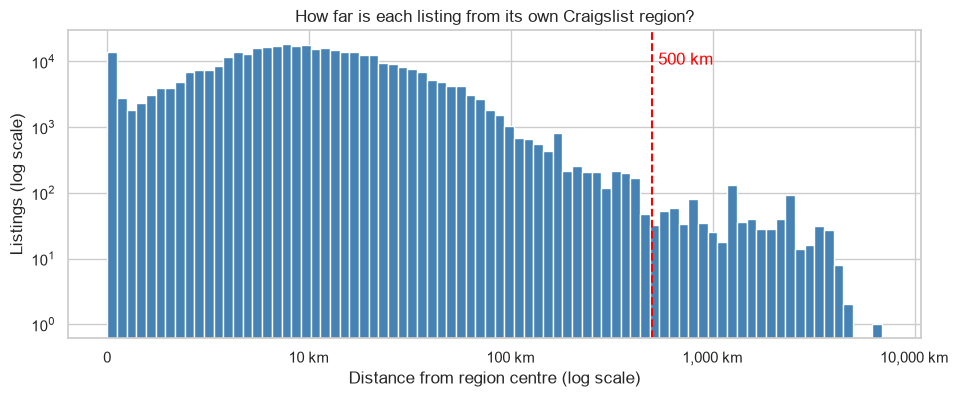

Listings more than 500 km from their region centre


,price,region,state,lat,long,description
110049,400,sioux city,ia,29.49,-94.92,"Fully furnished kitchen, 1 bedroom 1 bath apartment, all linens, just bring your clothes and tooth b"
353223,1550,mobile,al,34.05,-118.21,"138 N. Soto St, Los Angeles, CA, 90033 *NO parking on-site, only street parking. Live in a huge a"
153143,469,jackson,mi,32.31,-90.20,"Location: 1240 Lawnview Pl - Jackson, MS 39203 Rental Information:$469 /Month |1 Bedroom 1 Bath |"
159904,1780,minneapolis / st paul,mn,28.88,-81.21,"Welcome home to RiZE at Opus Park Apartments, a brand-new upscale mid-rise residential community fea"
91425,1050,la salle co,il,40.49,-104.71,3N- TR IN E2 SE4; REFERRED TO AS THE SE4 NE4 SE4 AS WELL AS THE NE4 SE4 SE4 LESS THE SOUTH 9' OF EAS
136984,1700,frederick,md,47.07,-122.39,"This 3 bedroom, 2.5 bath home has 1,370 square feet of living space. Leases signed in this state may"
376564,1350,los angeles,ca,37.96,-121.33,Charming guest house with private entrance attached to a large deck with an amazing view. Rent inc
66909,650,albany,ga,42.70,-73.90,2bed 2bath moost fabolous and nice Apartment for rent This brand new property is unlike any other i


In [ ]:
# 5.6 Distance from each listing to its region's centre

def haversine_km(lat1, lon1, lat2, lon2):
    # Great-circle distance in km between two points given in degrees
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    a = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    return 6371 * 2 * np.arcsin(np.sqrt(a))

good_coords = located & in_us
centres = df[good_coords].groupby("region_url")[["lat", "long"]].median()
centre_lat = df["region_url"].map(centres["lat"])
centre_lon = df["region_url"].map(centres["long"])

dist_km = pd.Series(np.nan, index=df.index)
dist_km[good_coords] = haversine_km(lat[good_coords], lon[good_coords],
                                    centre_lat[good_coords], centre_lon[good_coords])

print("Distance from region centre (km), located listings inside the U.S.:")
display(pct_index(dist_km.quantile([0.5, 0.9, 0.99, 0.999, 1])).rename("km").to_frame())

display(flag_table({f"more than {d:,} km from region centre": dist_km.gt(d) for d in [100, 250, 500, 1_000]}))

fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(np.log10(dist_km.dropna() + 1), bins=80, color="steelblue")
ax.set_yscale("log")
ax.axvline(np.log10(501), color="red", linestyle="--")
ax.text(np.log10(501) + 0.03, ax.get_ylim()[1] * 0.3, "500 km", color="red")
ax.set_xticks(range(5))
ax.set_xticklabels(["0", "10 km", "100 km", "1,000 km", "10,000 km"])
ax.set(xlabel="Distance from region centre (log scale)", ylabel="Listings (log scale)",
       title="How far is each listing from its own Craigslist region?")
save_fig("05_distance_from_region_centre")
plt.show()

far_from_region = dist_km.gt(FAR_KM)
print("Listings more than 500 km from their region centre")
peek(far_from_region, cols=["price", "region", "state", "lat", "long", "description"])

### 5.6 What our data showed, and the decision

**Most pins are close to their region:** the median distance is 8 km, and 99% of listings are within 140 km. But **827 listings (0.21%)** are more than 500 km away, some by thousands of kilometres.

**The examples show that both explanations happen, and often we can't tell which:**

- A listing on the **Albany, GA** site is pinned in **Albany, NY**. Another on the **Jackson, MI** site has a *Jackson, MS* address in its description. These are the ambiguous city names from Step 1.7, so the poster probably chose the wrong site, and the **pin** is right.
- A listing on the **Mobile, AL** site gives a Los Angeles street address and is pinned in Los Angeles. Again the **pin** is right, and the site is wrong.
- A brand-new complex on the **Minneapolis** site is pinned in central Florida. Here the **pin** looks wrong.

**Why this changes the decision:** the provisional plan was to blank the pin and trust the region. But in several examples the *region* is the wrong one, so blanking the pin would place a Los Angeles apartment in Alabama, with a Los Angeles rent. That teaches the model something false about Alabama. When the two location sources contradict each other and we can't tell which is right, the listing's location is unreliable.

**Decision:** **remove** listings more than 500 km from their region centre (`FAR_KM`), about 0.21% of rows. This differs from 5.5: a pin outside the U.S. is certainly wrong, so blanking it is safe. Here, either field could be the wrong one.

## 5.7 What does the `state` column really mean?

Step 1 noticed that listings from Reno (in Nevada) carry `state = ca`. This section checks why.

**What this cell does:**

1. It counts how many different `state` values each Craigslist site (`region_url`) has. If every site had exactly **one** state, `state` would simply be a label of the **site**, copied onto every listing from it.
2. It lists every site that has **more than one** state label, with how many listings carry each label.
3. It shows the Reno site as an example, including the centre of its listings. The centre is near 39.5° N, 119.8° W, which is Reno, Nevada.

**Why it matters:** we need to know what `state` means before using it as a model feature, and before deciding what the prediction platform should ask the user. If it's inconsistent *within* a site, the model sees two different labels for listings from the same place, which adds noise.

In [ ]:
# 5.7 Is state a property of the site or of the listing?

states_per_site = df.groupby("region_url")["state"].nunique()
print("Number of different state labels per Craigslist site:")
display(states_per_site.value_counts().sort_index().rename("sites").to_frame().T)

multi = states_per_site[states_per_site > 1].index
label_counts = (df[df["region_url"].isin(multi)]
                .groupby(["region_url", "state"]).size().rename("listings").reset_index())
label_counts["share_%"] = label_counts["listings"] / label_counts.groupby("region_url")["listings"].transform("sum") * 100
print(f"\nSites with more than one state label ({len(multi)}):")
display(label_counts.style.format({"listings": "{:,}", "share_%": "{:.1f}%"}))

centres_all = region_centres(df)
reno_sites = [u for u in centres_all.index if "reno" in u]
if reno_sites:
    print(f"Reno site centre: lat {centres_all.loc[reno_sites[0], 'lat']:.2f}, "
          f"long {centres_all.loc[reno_sites[0], 'long']:.2f}  (Reno, Nevada is about 39.5, -119.8)")

Number of different state labels per Craigslist site:


state,1,2
sites,399,14



Sites with more than one state label (14):


,region_url,state,listings,share_%
0,https://duluth.craigslist.org,mn,350,99.4%
1,https://duluth.craigslist.org,wi,2,0.6%
2,https://fortsmith.craigslist.org,ar,147,96.7%
3,https://fortsmith.craigslist.org,ok,5,3.3%
4,https://huntington.craigslist.org,ky,127,96.9%
5,https://huntington.craigslist.org,wv,4,3.1%
6,https://kansascity.craigslist.org,ks,"1,783",99.8%
7,https://kansascity.craigslist.org,mo,3,0.2%
8,https://lewiston.craigslist.org,id,24,88.9%
9,https://lewiston.craigslist.org,wa,3,11.1%


Reno site centre: lat 39.53, long -119.78  (Reno, Nevada is about 39.5, -119.8)


### 5.7 What our data showed, and the decision

**399 of the 413 sites have a single state label; 14 have two.** The two-label sites are metro areas that cross a state border. Reno/Tahoe carries both `ca` and `nv`, and earlier notebooks also showed Kansas City (`ks`/`mo`) and St. Louis (`mo`/`il`). So `state` is *mostly* a site label, but for border metros it's inconsistent, even though the listings come from the same local market.

**Decision:** give every listing the **most common state label of its site**. For example, all Reno/Tahoe listings get whichever of `ca` or `nv` is more common there. This makes `state` a consistent label of the Craigslist site ("the state this regional market is filed under"), and exact location is carried by `region_url` and the coordinates.

This rule uses no price information, so it can't cause leakage. It also fits the prediction platform nicely: the user picks a **region** from a list, and the platform fills in its state automatically, using the same mapping.

## 5.8 Homes for sale hiding in the rental data

Step 2 found listings that are **homes for sale**, not rentals, such as manufactured homes at \$78,500 with a separate "lot rent". Those were above \$10,000, so the price rule already removes them. But a cheap sale listing (an old mobile home for \$6,000, or a monthly *loan payment*) could sit **inside** the valid price range and look like a normal rent.

**What this cell does:** it searches every description for wording that signals a sale and reports, for each pattern:

- how many listings match (all rows, and in the valid price range);
- their median price, compared with the overall median;
- what share of them are **manufactured homes**, the type most often sold this way.

The patterns are **regular expressions**: small search rules. `\b` means "word boundary", so `\bfor sale\b` finds "for sale" as whole words but not inside other words. The search is case-insensitive because the text is converted to lower case first.

**Two patterns are included only for comparison, not as sale evidence:**

- **"rent to own"** is a rental arrangement: the tenant pays rent, part of which may go towards buying later. The monthly price *is* a rent.
- **"lot rent"** often appears in manufactured-home parks, even for homes that are rented.

**How to read the output:** a pattern is a good removal rule only if its examples really are sales. "For sale" can occasionally appear innocently ("furniture for sale", "house for sale or rent"), so the next cell shows each match **in context**, the words around it, so you can judge.

In [ ]:
# 5.8 Search descriptions for sale wording

desc = df["description"].fillna("").str.lower()
overall_median = df.loc[valid, "price"].median()

sale_patterns = {
    "for sale": r"\bfor sale\b",
    "down payment": r"\bdown ?payment\b",
    "purchase / sale / asking price": r"\b(?:purchase|sale|sales|asking) price\b",
    "owner / in-house financing": r"\b(?:owner|in[- ]house) financ",
    "rent to own (comparison only)": r"\brent[- ]to[- ]own\b",
    "lot rent (comparison only)": r"\blot rent\b",
}

pattern_hits = {name: desc.str.contains(rx, regex=True) for name, rx in sale_patterns.items()}
rows = []
for name, hit in pattern_hits.items():
    in_valid = hit & valid
    rows.append({
        "pattern": name,
        "listings": int(hit.sum()),
        "in_valid_price_range": int(in_valid.sum()),
        "median_price_valid": df.loc[in_valid, "price"].median(),
        "manufactured_%": (df.loc[in_valid, "type"] == "manufactured").mean() * 100 if in_valid.any() else np.nan,
    })
sale_table = pd.DataFrame(rows).set_index("pattern")
print(f"Overall median valid price: ${overall_median:,.0f}   |   "
      f"manufactured share overall: {(df.loc[valid, 'type'] == 'manufactured').mean() * 100:.1f}%")
sale_table.style.format({"listings": "{:,}", "in_valid_price_range": "{:,}",
                         "median_price_valid": "${:,.0f}", "manufactured_%": "{:.1f}%"}, na_rep="-")

Overall median valid price: $1,040   |   manufactured share overall: 1.1%


,listings,in_valid_price_range,median_price_valid,manufactured_%
pattern,,,,
for sale,794,732,"$1,250",29.2%
down payment,826,783,"$1,085",23.2%
purchase / sale / asking price,319,314,"$1,290",34.4%
owner / in-house financing,180,169,"$1,050",26.6%
rent to own (comparison only),"1,900","1,886",$806,4.2%
lot rent (comparison only),418,403,$795,95.5%


### 5.8 (cont.) Reading the matches in context

**What this cell does:** it combines the four sale patterns (not the two comparison patterns) into one **strong sale rule**. Then, for a random sample of matching listings inside the valid price range, it shows the words around the match. Seeing "…3 bed 2 bath home **for sale**, \$5,000 down…" makes it obvious the price isn't a monthly rent, while "…washer and dryer **for sale** by previous tenant…" would be a false alarm.

**How to decide:** if most examples are genuine sales, the strong rule would become a removal rule. If many are false alarms, the rule would remove real rentals, which is worse than keeping a few sales.

In [ ]:
# 5.8 (cont.) The strong sale rule, with matches shown in context

STRONG_SALE = r"\bfor sale\b|\bdown ?payment\b|\b(?:purchase|sale|sales|asking) price\b|\b(?:owner|in[- ]house) financ"
sale_listing = desc.str.contains(STRONG_SALE, regex=True)

def in_context(text, pattern=STRONG_SALE, width=70):
    m = re.search(pattern, text)
    if not m:
        return ""
    start, end = max(m.start() - width, 0), m.end() + width
    return "..." + text[start:end].replace("\n", " ") + "..."

sample = df[sale_listing & valid].sample(min(10, int((sale_listing & valid).sum())), random_state=RANDOM_STATE)
context = sample[["price", "type", "region", "state"]].copy()
context["match_in_context"] = desc.loc[sample.index].apply(in_context)
with pd.option_context("display.max_colwidth", 200):
    display(context)

print(f"Strong sale rule flags {sale_listing.sum():,} listings, {(sale_listing & valid).sum():,} in the valid price range")

,price,type,region,state,match_in_context
228420,745,house,cleveland,oh,"...ry, there are terrific programs for you as well!! features include a down payment grant, closing costs paid for you, special tax abatement, low interes..."
368616,1500,apartment,bakersfield,ca,...>recently touched up 3 bedroom 2 bath home on a sleepy cul de sac lot for sale. this home features freshly cleaned carpets and new interior paint. t...
267067,500,house,greenville / upstate,sc,...have you wanted to buy a home but couldn't come up with enough of a down payment for a loan or couldn't get approved for a loan? then give rent to own...
257933,1100,house,scranton / wilkes-barre,pa,"...for sale or lease by owner 1711 luzerne st, west scranton. 2 bed, 1 tile b..."
377865,1550,townhouse,modesto,ca,...as maintained by the association with space for gardening if desired asking price for rent is $1550 per month or best offer. deposit will be $1200. uti...
28995,1800,apartment,new haven,ct,"...otos & listings or visit www.seaburyhill.com to search for properties for sale in new haven, the shoreline &; surrounding towns..."
258865,832,manufactured,york,pa,...brand new 2020 manufactured home for sale! move-in ready! lot rent for this home is at $425 including sewer an...
359877,1700,apartment,phoenix,az,"...my client just purchased the property and pictures are relfecting the for sale sign because we are using them from the for sale listing. call, text ..."
341238,1100,house,kenosha-racine,wi,".... $1,100.00 for two people - others additional or best offer. the for sale sign will be removed and the property will be taken off the market if..."
28933,1100,house,new haven,ct,"...must be employed, must have minimum 550 credit score, must have small down payment, must be owner occupied (sorry, no investors unless you are prequalif..."


Strong sale rule flags 1,794 listings, 1,691 in the valid price range


### 5.8 What our data showed, and the decision

**The sale patterns do concentrate in manufactured homes:** 23–34% of matches, vs 1.1% of all listings. So sale listings exist, as Step 2 suggested.

**But the examples show that the rule is unreliable.** Of the 10 matches shown in context, only about 4 are genuine sales ("3 bedroom 2 bath home… lot for sale", "brand new 2020 manufactured home for sale"). The others are **false alarms from real rentals**:

- "features include a **down payment** grant": a rental advertising a home-buying programme;
- "**asking price** for rent is \$1…": a rental;
- "search for properties **for sale** in New Haven": an agent's website boilerplate;
- "pictures reflecting the **for sale** sign": a rental whose photos were taken before the owner bought it.

**The prices confirm it:** matching listings have median prices of \$1,085–\$1,290, close to the overall median of \$1,040. They behave like rents, not like sale prices.

**Decision:** **no text-based removal rule.** A rule that removes real rentals about as often as it removes sales does more harm than good. The expensive sale listings are already removed by the \$10,000 price limit (Step 2). Any sale listings left inside the valid range are a **known limitation**, stated in the report. This also keeps the cleaning rules independent of free text, which the prediction platform never receives anyway.

## 5.9 The heavy lower tail: rents of \$100–\$249

Step 2's Q-Q plot showed more very cheap rents than a normal shape would predict. This cell asks: **what are these listings?** There are three likely explanations, and each needs a different response:

1. **Weekly prices.** Some motels and extended-stay places advertise "\$199 per week". Entered as the monthly price, that's wrong by a factor of about 4.3.
2. **Rooms and shared housing.** "Private room for rent, \$225". This is a real monthly rent, but for a *room*, not a whole home.
3. **Genuinely cheap housing,** such as an old trailer in a rural area.

**What this cell does:** it searches the descriptions for weekly-price and room/shared wording, and compares **how often each appears in the \$100–\$249 band vs in all valid listings**. If weekly wording is, say, 10 times more common among these cheap listings than overall, that strongly suggests many of them are weekly prices.

It also computes **price per square foot** (`price / sqfeet`) for the cheap band vs all listings. A whole 900 sq ft home for \$150 gives \$0.17 per sq ft, far below any normal rent. That signals a wrong price or wrong size rather than a real bargain.

**How to read the output:** the "times more common" column is the key number. Values well above 1 mean that kind of listing is concentrated in the cheap band.

In [ ]:
# 5.9 What are the $100-$249 listings?

low_band = valid & df["price"].between(PRICE_MIN, 249)
print(f"Listings priced ${PRICE_MIN}-$249: {low_band.sum():,} ({low_band.sum() / valid.sum() * 100:.2f}% of valid rows)")

wording = {
    "weekly price": r"weekly|\bper week\b|/ ?week\b|/ ?wk\b|\ba week\b",   # no \b before "weekly": also catches "_weekly"
    "room / shared / roommate": r"\broom for rent\b|\bprivate room\b|\bshared\b|\broommate",
    "deposit / move-in special": r"\bdeposit\b|\bmove[- ]in special",
}
rows = []
for name, rx in wording.items():
    hit = desc.str.contains(rx, regex=True)
    share_low = hit[low_band].mean() * 100
    share_all = hit[valid].mean() * 100
    rows.append({"wording": name, "%_in_$100-249": share_low, "%_in_all_valid": share_all,
                 "times_more_common": share_low / share_all if share_all > 0 else np.nan})
display(pd.DataFrame(rows).set_index("wording")
          .style.format({"%_in_$100-249": "{:.1f}%", "%_in_all_valid": "{:.1f}%", "times_more_common": "{:.1f}x"}))

ppsf = df["price"] / df["sqfeet"].where(df["sqfeet"] > 0)
print("Price per sq ft (median):")
print(f"   $100-$249 band: ${ppsf[low_band].median():.2f}")
print(f"   all valid rows: ${ppsf[valid].median():.2f}")

weekly_low = low_band & desc.str.contains(wording["weekly price"], regex=True)
print("\nCheap listings that mention weekly pricing")
peek(weekly_low)
print("Other cheap listings")
peek(low_band & ~weekly_low)

Listings priced $100-$249: 694 (0.18% of valid rows)


,%_in_$100-249,%_in_all_valid,times_more_common
wording,,,
weekly price,72.6%,2.2%,33.6x
room / shared / roommate,1.9%,5.6%,0.3x
deposit / move-in special,46.1%,26.1%,1.8x


Price per sq ft (median):
   $100-$249 band: $0.58
   all valid rows: $1.12

Cheap listings that mention weekly pricing


,price,type,sqfeet,beds,baths,region,state,description
196258,249,apartment,380,1,1.00,las vegas,nv,Welcome to Budget Suites where you can make one of our apartments your home for a week or beyond! Bu
205744,184,apartment,350,0,1.00,albuquerque,nm,"Move In Today to Siegel Suites Albuquerque: Low-Cost, Clean Furnished Apartments - Close to Restaura"
346814,200,apartment,750,1,1.00,wyoming,wy,"PARTLY FURNISHED 1 BEDROOM APARTMENT $200 PER PERSON, PER WEEK. INCLUDES OWN BATHROOM, BEDROOM, AN"
76829,175,apartment,300,1,1.00,macon / warner robins,ga,OK...so you are in a tough situation trying to make your rental payments every month. If only you co
221673,185,apartment,300,1,1.00,north dakota,nd,OK...so you are in a tough situation trying to make your rental payments every month. If only you co
76860,175,apartment,300,1,1.00,macon / warner robins,ga,OK...so you are in a tough situation trying to make your rental payments every month. If only you co
297220,239,apartment,383,1,1.00,dallas / fort worth,tx,Welcome to Budget Suites where you can make one of our apartments your home for a week or beyond! Bu
172602,150,apartment,300,1,1.00,springfield,mo,"Are you a professional staying in Branson on work assignment, theater or singing performance? We hav"


Other cheap listings


,price,type,sqfeet,beds,baths,region,state,description
356449,200,cottage/cabin,180,1,0.00,anchorage / mat-su,ak,"Dry cabin for rent, located 120 mile north of anchorage and 2 mile off the highway. 9'-6""X19' dry c"
370767,218,apartment,842,2,1.00,fresno / madera,ca,"Your New Home Welcome to Park Ridge , A Beautiful Place to Live Call Now: show contact info Park Ri"
194890,186,house,672,2,1.00,scottsbluff / panhandle,ne,Open family room and dining room. Fresh paint and new carpet. Laundry room off the kitchen. Large ba
107685,100,apartment,1170,2,2.00,omaha / council bluffs,ia,Come home for the holidays! Our property is currently undergoing a multi-million dollar renovation!
171578,230,apartment,1,4,2.00,columbia / jeff city,mo,"I have sign a lease to a apartment on 5151 Commercial Dr, But with school itâs hard to live there"
6994,120,house,2000,3,2.00,santa barbara,ca,Escape to the country 2000 sq ft adobe ranch house on 40 acres enjoy hiking in nearby Pinnacles nati
1067,249,apartment,270,0,1.00,reno / tahoe,ca,"Move In Today: Low-Cost, Furnished Apartments in Reno! Call Us! Move In Today! show contact info"
21259,109,apartment,672,1,1.00,denver,co,"Terra Vista at the Park 5425 S. Federal Circle, Littleton, CO, 80123 Call Now - show contact info"


### 5.9 What our data showed, and the decision

The \$100–\$249 band is small (694 listings, 0.18% of valid rows), but almost none of it is ordinary monthly rent:

- **Weekly wording is 34 times more common** here than in all listings: 72% vs 2%. The examples are extended-stay hotels ("weekly special at Extended Studio Hotel starting at \$245", "\$190 + tax weekly, single occupancy") and furnished rooms by the week.
- **Room / shared wording is *less* common** here (0.3×), so the idea that these are cheap rooms is **not** supported.
- **The rest** include a nightly beach vacation rental, a house "to be sold as is", and a \$112 listing that's most likely an application fee.
- Median price per sq ft is \$0.58, about half the normal \$1.12. These listings are too cheap for their size to be monthly rents.

**Decision:** instead of a text rule for weekly prices (the first version of this notebook), raise the effective lower price limit to **\$250** (`RENT_FLOOR`). It's simpler, it removes the weekly rates *and* the other non-rents in the same band, and it doesn't depend on free text. Step 2's \$100 limit was the right first cut for the obvious placeholders (\$0, \$1). This step refines it with evidence Step 2 didn't have.

## 5.10 Putting it together: the cleaning function and the data funnel

All the confirmed rules from Steps 2–5 are now written **once** as a Python function, `clean_data()`, in `src/cleaning.py`. This cell simply calls it. From now on, every notebook, the training code, and the report's numbers come from this one function, so they can never disagree.

**What `clean_data()` does, in order:**

1. **Price rule** (Steps 2 and 5.9): keep \$250 to \$10,000.
2. **Core facts** (Steps 5.1–5.4): remove rows with an invalid size, bedrooms or bathrooms, under 70 sq ft per room, or more than `beds + 3` bathrooms.
3. **Location** (Steps 5.5–5.6): blank pins outside the U.S. (kept, filled later); remove listings more than 500 km from their region centre.
4. **State** (Step 5.7): one state label per Craigslist site.
5. **Deduplication** (Step 4): one row per group of listings that are identical to the model.

**Why this order?** Deduplication comes **last**, as decided in Step 4. Rules that change values (blanking pins, relabelling state) can make two copies of a listing identical. For example, the Reno copies labelled `ca` and `nv`, or two reposts with slightly different broken pins, both of which become blank. Deduplicating after those changes catches these copies. Deduplicating first would miss them.

**Why `through_step=5`?** `clean_data()` also contains the Step 6 rules (price per sq ft and non-home types), which were added after notebook 05. The Step 6 notebook needs to look at the data *before* those rules, so here we stop after Step 5 and save the result as `housing_step5.parquet`. The final, fully cleaned dataset is made in Step 7 (notebook 06).

**How to read the funnel:** each stage shows how many rows remain and how many that stage removed. Expect the validity rules to remove only a small share, and deduplication to remove about half, which matches Step 4.

**Leakage check:** no rule uses prices to decide *which* listings to keep, except the fixed price limits themselves. The region centres in step 3 use only coordinates. So the whole function can run before the train/test split without leaking test information.

clean_data: 384,977 -> 188,546 rows (49.0% kept); 260 pins outside the U.S. blanked


,rows,removed,%_of_raw_remaining
stage,,,
1. Raw data,"384,977",0,100.0%
"2. Price $250-$10,000 (Steps 2, 5.9)","381,800","3,177",99.2%
"3. Valid size, beds, baths (Steps 5.1-5.4)","377,572","4,228",98.1%
4. Location consistent (Steps 5.5-5.6),"376,776",796,97.9%
5. Deduplicated (Step 4),"188,546","188,230",49.0%


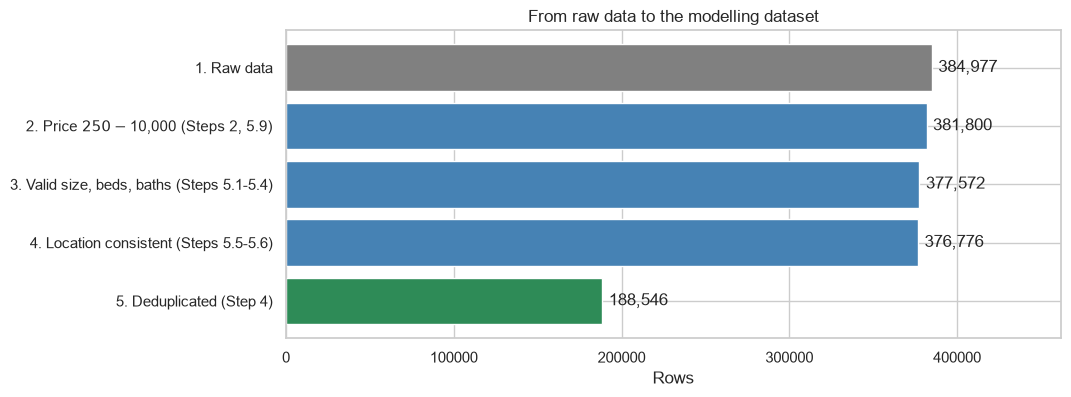

Saved 188,546 rows to data\processed\housing_step5.parquet


In [ ]:
# 5.10 The cleaning function and the data funnel

df_clean, funnel = clean_data(df_raw, through_step=5)   # Step 6 rules are analysed in notebook 05
display(funnel.style.format({"rows": "{:,}", "removed": "{:,}", "%_of_raw_remaining": "{:.1f}%"}))

fig, ax = plt.subplots(figsize=(10, 4))
colors = ["grey"] + ["steelblue"] * (len(funnel) - 2) + ["seagreen"]
ax.barh(funnel.index[::-1], funnel["rows"][::-1], color=colors[::-1])
for i, v in enumerate(funnel["rows"][::-1]):
    ax.text(v + len(df_raw) * 0.01, i, f"{v:,}", va="center")
ax.set_xlim(0, len(df_raw) * 1.2)
ax.set(xlabel="Rows", title="From raw data to the modelling dataset")
save_fig("05_data_funnel")
plt.show()

# Save the data after Steps 2-5: the Step 6 notebook starts from this file
df_clean.to_parquet(STEP5_FILE, index=False)
print(f"Saved {len(df_clean):,} rows to {STEP5_FILE.relative_to(ROOT)}")

## 5.11 Log the Step 5 observations

As in the earlier notebooks, `clear_obs("5")` removes older Step 5 entries first, and the numbers are filled in from your results. The decisions now describe the **confirmed** rules, which are the ones implemented in `clean_data()`.

In [ ]:
# 5.11 Log the observations

clear_obs("5")

def n_in_valid(mask):
    return f"{int(mask.sum()):,} listings ({int((mask & valid).sum()):,} in the valid price range)"

zero_baths = df["baths"].eq(0)

log_obs("5-Validity",
        f"sqfeet: {int(sq.eq(0).sum()):,} zeros, {int(sq.lt(100).sum()):,} under 100 (typos such as a 35 sq ft 2-bed condo); "
        f"above 10,000 are placeholders/typos; outside {SQFT_MIN}-{SQFT_MAX:,}: {n_in_valid(bad_sqft)}",
        "5.1 quantiles, threshold counts, repeated values, examples",
        f"Remove rows with sqfeet outside {SQFT_MIN}-{SQFT_MAX:,} (size is a core user input; no guessing)")

log_obs("5-Validity",
        f"beds 0-8 all plausible (0 = studio); above {BEDS_MAX}: only {int(beds.gt(BEDS_MAX).sum())} listings, "
        f"with {sorted(beds[beds.gt(BEDS_MAX)].unique().tolist())} beds",
        "5.2 value counts and examples",
        f"Remove rows with beds > {BEDS_MAX}")

log_obs("5-Validity",
        f"{int(zero_baths.sum()):,} listings have 0 baths and the examples are ordinary apartments, so 0 means "
        f"'not entered'; {int(baths.gt(BATHS_MAX).sum())} above {BATHS_MAX}; half-baths all valid",
        "5.3 value counts and examples",
        f"Remove rows with baths outside {BATHS_MIN}-{BATHS_MAX}")

log_obs("5-Validity",
        f"Under {MIN_SQFT_PER_ROOM} sq ft per room: {n_in_valid(tiny_rooms)}; baths > beds + {MAX_EXTRA_BATHS}: "
        f"{n_in_valid(too_many_baths)}; all examples were typos or per-room pricing",
        "5.4 consistency checks and examples",
        "Remove both (impossible size/room combinations; per-room prices are not whole-unit rents)")

log_obs("5-Validity",
        f"Pins outside the U.S.: {n_in_valid(outside_us)}, almost all a positive longitude "
        f"(one complex posted many times)",
        "5.5 bounding-box checks and examples",
        "Blank these coordinates (listing kept) and use the Step 3 regional fill; no sign-flip repairs")

log_obs("5-Validity",
        f"Pins more than {FAR_KM} km from their region centre: {n_in_valid(far_from_region)}; causes include "
        f"wrong pins AND listings posted on the wrong site (e.g. Albany GA vs Albany NY)",
        "5.6 haversine distances and examples",
        "Remove: region and pin contradict each other and we can't tell which is right")

log_obs("5-Validity",
        f"{int((states_per_site > 1).sum())} of {len(states_per_site)} Craigslist sites carry two state labels "
        f"(border metros, e.g. Reno/Tahoe ca and nv)",
        "5.7 state labels per site",
        "Give each listing its site's most common state label; the platform derives state from the chosen region")

log_obs("5-Validity",
        f"Sale wording matches {n_in_valid(sale_listing)}, but about half the examples are real rentals "
        f"(down payment grants, agent boilerplate) and match prices look like rents",
        "5.8 pattern table and matches in context",
        "No text-based removal rule; remaining sale listings noted as a limitation")

weekly_hit = desc.str.contains(wording["weekly price"], regex=True)
weekly_ratio = weekly_hit[low_band].mean() / weekly_hit[valid].mean()
log_obs("5-Validity",
        f"{int(low_band.sum()):,} listings priced $100-$249: weekly wording {weekly_ratio:.0f}x more common than overall, "
        f"room wording less common; others are nightly, sale or fee listings",
        "5.9 wording comparison, price per sq ft, examples",
        f"Raise the effective price floor to ${RENT_FLOOR} (RENT_FLOOR)")

stage_rows = funnel["rows"]
log_obs("5-Validity",
        "Modelling dataset: " + " -> ".join(f"{v:,}" for v in stage_rows)
        + f" rows ({stage_rows.iloc[-1] / stage_rows.iloc[0] * 100:.1f}% of raw kept)",
        "5.10 clean_data() funnel",
        "All rules implemented once in src/cleaning.py; data after Steps 2-5 saved to data/processed/housing_step5.parquet")

show_obs(5)

,step,observation,evidence,decision
0,5-Validity,"sqfeet: 48 zeros, 976 under 100 (typos such as...","5.1 quantiles, threshold counts, repeated valu...","Remove rows with sqfeet outside 100-10,000 (si..."
1,5-Validity,beds 0-8 all plausible (0 = studio); above 8: ...,5.2 value counts and examples,Remove rows with beds > 8
2,5-Validity,"3,107 listings have 0 baths and the examples a...",5.3 value counts and examples,Remove rows with baths outside 0.5-8
3,5-Validity,Under 70 sq ft per room: 114 listings (113 in ...,5.4 consistency checks and examples,Remove both (impossible size/room combinations...
4,5-Validity,Pins outside the U.S.: 262 listings (262 in th...,5.5 bounding-box checks and examples,Blank these coordinates (listing kept) and use...
5,5-Validity,Pins more than 500 km from their region centre...,5.6 haversine distances and examples,Remove: region and pin contradict each other a...
6,5-Validity,14 of 413 Craigslist sites carry two state lab...,5.7 state labels per site,Give each listing its site's most common state...
7,5-Validity,"Sale wording matches 1,794 listings (1,691 in ...",5.8 pattern table and matches in context,No text-based removal rule; remaining sale lis...
8,5-Validity,694 listings priced $100-$249: weekly wording ...,"5.9 wording comparison, price per sq ft, examples",Raise the effective price floor to $250 (RENT_...
9,5-Validity,"Modelling dataset: 384,977 -> 381,800 -> 377,5...",5.10 clean_data() funnel,All rules implemented once in src/cleaning.py;...


---

## Step 5 – Summary of findings

| Check | What we found | Decision |
|---|---|---|
| Size (5.1) | 976 listings under 100 sq ft are typos (a 35 sq ft 2-bed condo); above 10,000 are placeholders and typos (17,951 for "1795 sq ft") | Keep 100–10,000 sq ft; remove 1,058 rows (0.27%) |
| Bedrooms (5.2) | 0–8 all plausible; only 4 listings above 8, with 1,000 or 1,100 beds | Keep 0–8 |
| Bathrooms (5.3) | **0 baths (3,107) means "not entered"**: the examples are ordinary apartments; only 5 above 8 | Keep 0.5–8; remove 0-bath rows |
| Size vs rooms (5.4) | 122 listings under 70 sq ft per room (typos, rooms by the week); all 32 with baths > beds + 3 were errors or per-room pricing | Remove both |
| Pins outside U.S. (5.5) | 262 listings, almost all a flipped longitude sign from one complex | Blank the pin, keep the listing |
| Pins far from region (5.6) | 827 listings > 500 km away: wrong pins **and** listings on the wrong site (Albany GA vs NY, Jackson MI vs MS) | Remove: the location is contradictory |
| State labels (5.7) | 14 of 413 sites carry two labels (border metros such as Reno ca/nv) | One label per site (its most common) |
| Sale wording (5.8) | Concentrated in manufactured homes, but about half the matches are real rentals, and match prices look like rents | **No text rule**; limitation in report |
| \$100–\$249 rents (5.9) | 72% mention weekly pricing (34× normal); the rest are nightly, sale or fee listings | Raise the price floor to **\$250** |

**The most important lesson of Step 5:** three of the provisional rules changed after reading real examples: 0 baths, the far-away pins, and the sale wording. Counting and thresholds find *candidates*. Only looking at actual listings tells you what they are. That's worth saying in the report, because it shows the rules are evidence-based rather than arbitrary.

**The data after Steps 2–5** is saved as `data/processed/housing_step5.parquet`. See 5.10 for the exact number of rows at each stage. Step 6 starts from this file.

---

## What's next: Step 6 – Outliers and feature distributions (`05_eda_outliers.ipynb`)

Step 5 removed values that are **impossible**. Step 6 works on the **clean, deduplicated** data and looks at values that are **possible but unusual**, which is the difference between an error and an extreme:

- the shape of each numeric feature (`sqfeet`, `beds`, `baths`, coordinates): skewed? does it need a transform?
- **price per square foot**, which catches leftovers such as the 9,999 sq ft one-bed apartment in Boston;
- the high-end rentals near \$10,000, by state (a lead from Step 2);
- rare property types such as `land` and `assisted living` (from Step 1).